# 01 — Exploratory Data Analysis

In [ ]:
import sys
sys.path.append('..')
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..') 

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.components.data_ingestion import DataIngestion

sns.set_theme(style='darkgrid')

di = DataIngestion()
X_prof, y_prof, pt_prof, X_atk, y_atk, pt_atk = di.initiate_data_ingestion()
print(f'X_prof: {X_prof.shape} | y_prof: {y_prof.shape}')
print(f'X_atk:  {X_atk.shape}  | y_atk:  {y_atk.shape}')

X_prof: (50000, 700) | y_prof: (50000,)
X_atk:  (10000, 700)  | y_atk:  (10000,)


## 1. Raw Power Traces

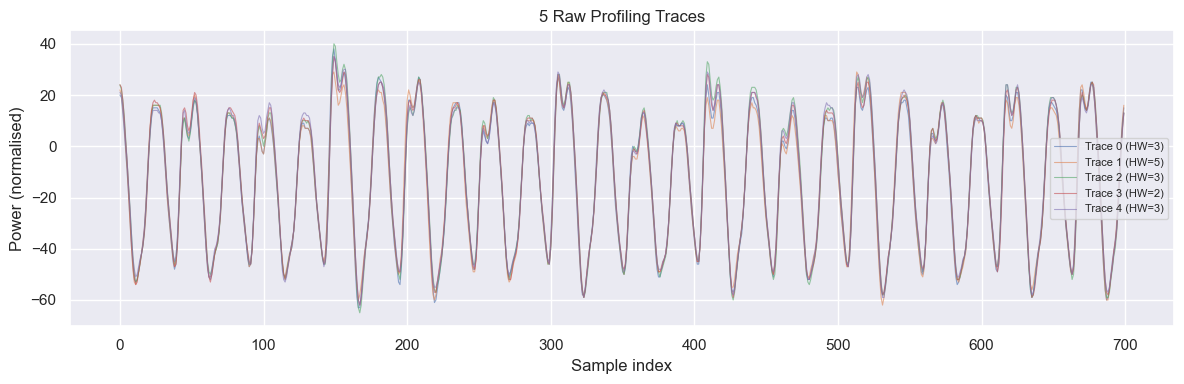

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
for i in range(5):
    ax.plot(X_prof[i], alpha=0.6, linewidth=0.8, label=f'Trace {i} (HW={y_prof[i]})')
ax.set_xlabel('Sample index')
ax.set_ylabel('Power (normalised)')
ax.set_title('5 Raw Profiling Traces')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('artifacts/raw/plot_raw_traces.png', dpi=150)
plt.show()

## 2. HW Label Distribution

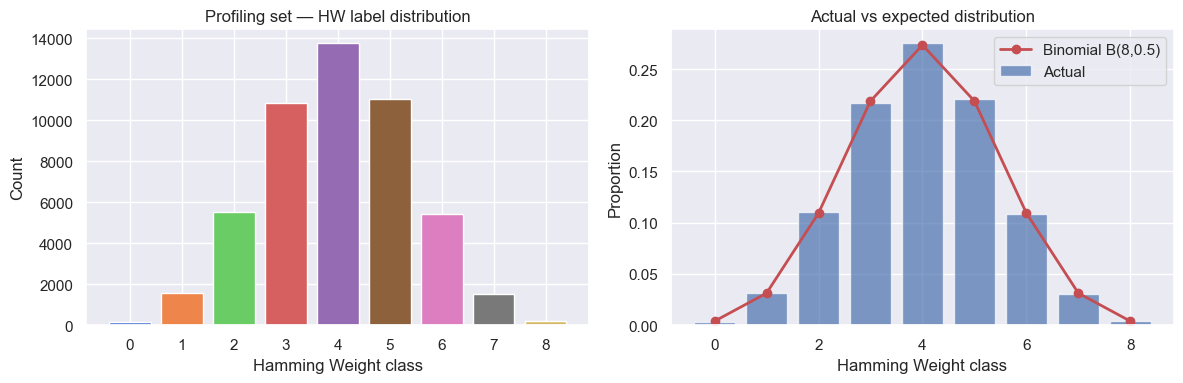

Class counts: {np.int32(0): np.int64(166), np.int32(1): np.int64(1568), np.int32(2): np.int64(5500), np.int32(3): np.int64(10848), np.int32(4): np.int64(13747), np.int32(5): np.int64(11023), np.int32(6): np.int64(5416), np.int32(7): np.int64(1532), np.int32(8): np.int64(200)}


In [ ]:
classes, counts = np.unique(y_prof, return_counts=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(classes, counts, color=sns.color_palette('muted', len(classes)))
axes[0].set_xlabel('Hamming Weight class')
axes[0].set_ylabel('Count')
axes[0].set_title('Profiling set — HW label distribution')
axes[0].set_xticks(classes)

from math import comb
expected = np.array([comb(8, k) * (0.5**8) for k in classes])
axes[1].bar(classes, counts / counts.sum(), label='Actual', alpha=0.7)
axes[1].plot(classes, expected, 'r-o', label='Binomial B(8,0.5)', linewidth=2)
axes[1].set_xlabel('Hamming Weight class')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Actual vs expected distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('artifacts/raw/plot_label_dist.png', dpi=150)
plt.show()
print('Class counts:', dict(zip(classes, counts)))

## 3. SNR Plot

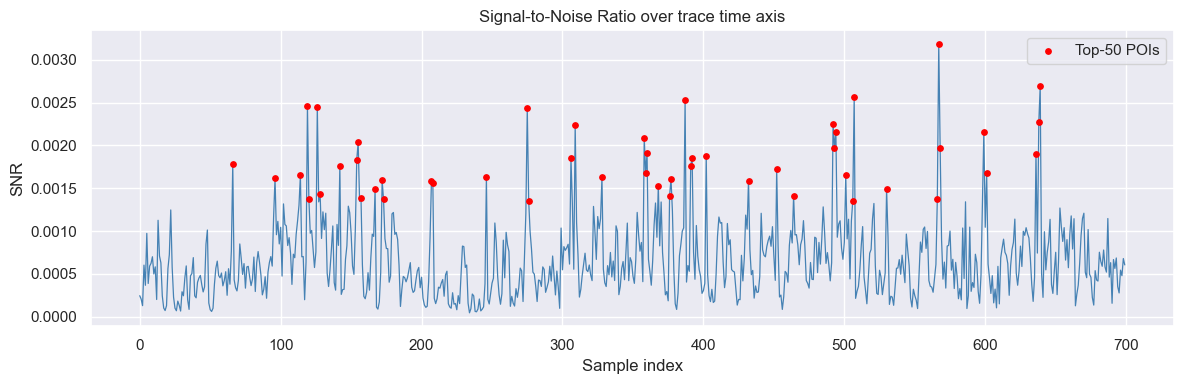

Max SNR: 0.0032 at sample 567
Top-10 POI indices: [567 639 507 387 119 126 275 638 492 309]


In [ ]:
def compute_snr(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """SNR[t] = Var(class means at t) / Mean(within-class var at t)"""
    classes = np.unique(y)
    class_means = np.array([X[y == c].mean(axis=0) for c in classes])
    signal = class_means.var(axis=0)                                    # (700,)
    noise  = np.array([X[y == c].var(axis=0) for c in classes]).mean(axis=0)  # (700,)
    return signal / (noise + 1e-12)

snr = compute_snr(X_prof, y_prof)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(snr, linewidth=0.9, color='steelblue')
ax.set_xlabel('Sample index')
ax.set_ylabel('SNR')
ax.set_title('Signal-to-Noise Ratio over trace time axis')

top50 = np.argsort(snr)[-50:]
ax.scatter(top50, snr[top50], color='red', s=15, zorder=5, label='Top-50 POIs')
ax.legend()

plt.tight_layout()
plt.savefig('artifacts/raw/plot_snr.png', dpi=150)
plt.show()
print(f'Max SNR: {snr.max():.4f} at sample {snr.argmax()}')
print(f'Top-10 POI indices: {np.argsort(snr)[-10:][::-1]}')

## 4. Mean Trace per HW Class

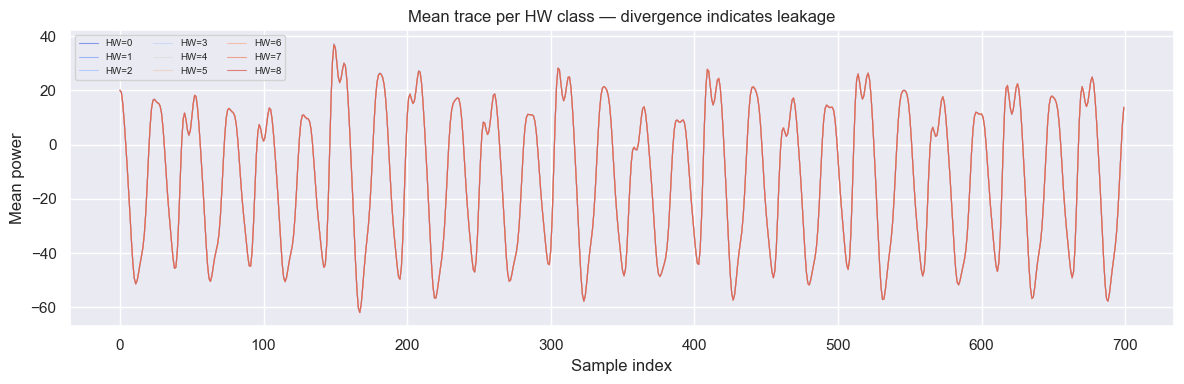

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
palette = sns.color_palette('coolwarm', 9)
for hw in sorted(np.unique(y_prof)):
    mean_trace = X_prof[y_prof == hw].mean(axis=0)
    ax.plot(mean_trace, alpha=0.7, linewidth=0.8,
            color=palette[hw], label=f'HW={hw}')
ax.set_xlabel('Sample index')
ax.set_ylabel('Mean power')
ax.set_title('Mean trace per HW class — divergence indicates leakage')
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.savefig('artifacts/raw/plot_mean_per_class.png', dpi=150)
plt.show()

## 5. Summary Statistics

In [13]:
print('=== Dataset Summary ===')
print(f'Profiling traces : {X_prof.shape[0]:,} × {X_prof.shape[1]} samples')
print(f'Attack traces    : {X_atk.shape[0]:,} × {X_atk.shape[1]} samples')
print(f'Dtype            : {X_prof.dtype}')
print(f'Trace value range: [{X_prof.min():.2f}, {X_prof.max():.2f}]')
print(f'Target byte index: 2  |  Correct key byte: 0xe0 = {0xe0}')
print(f'HW classes present: {sorted(np.unique(y_prof))}')
print(f'SNR peak sample  : {snr.argmax()} (value={snr.max():.4f})')
print()
print('Class imbalance check (profiling):')
for c, n in zip(classes, counts):
    print(f'  HW={c}: {n:,} ({100*n/len(y_prof):.1f}%)')

=== Dataset Summary ===
Profiling traces : 50,000 × 700 samples
Attack traces    : 10,000 × 700 samples
Dtype            : float32
Trace value range: [-66.00, 47.00]
Target byte index: 2  |  Correct key byte: 0xe0 = 224
HW classes present: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8)]
SNR peak sample  : 567 (value=0.0032)

Class imbalance check (profiling):
  HW=0: 166 (0.3%)
  HW=1: 1,568 (3.1%)
  HW=2: 5,500 (11.0%)
  HW=3: 10,848 (21.7%)
  HW=4: 13,747 (27.5%)
  HW=5: 11,023 (22.0%)
  HW=6: 5,416 (10.8%)
  HW=7: 1,532 (3.1%)
  HW=8: 200 (0.4%)
